# Fase 2 — Baseline smart persistence (nodo 1736)

Referencia obligatoria `kt(t+1)=kt(t)` que todo modelo debe superar (skill > 0).
Se reconstruye GHI como `kt_pred * clearsky_ghi` y se evalúa **solo en horas
operativas** (`clearsky_ghi>0` y `solar_zenith_angle<85`), con partición temporal
train 2020-22 / val 2023 / test 2024.

**Dos variantes** por la discontinuidad noche→mañana:
- **A (carry-forward):** usa el último kt operativo (salta la noche). Cubre todas
  las horas operativas → es el `RMSE_ref` de la tarea completa para la Fase 3.
- **B (pares consecutivos):** usa kt(t-1) solo si t-1 fue operativa; descarta la 1ª
  hora de cada mañana. Es la persistencia de 1 h "pura" (diagnóstico).

**fill_flag:** no se filtra el target; se reporta métrica global + segmentada
(limpio ff=0 vs rellenado ff>0). El skill del baseline se mide contra el predictor
tonto de cielo despejado (kt=1).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from forecasting import config as C
from forecasting.data.loaders import cargar_serie_nodo
from forecasting.eval import persistence as P, reporte as R

df = cargar_serie_nodo(1736)
per = P.smart_persistence(df)
print('serie:', df.index.min(), '->', df.index.max(), '| filas:', len(df))
print('horas operativas:', int(per['op'].sum()))

serie: 2020-01-01 00:00:00 -> 2024-12-31 23:00:00 | filas: 43848
horas operativas: 20586


## Tabla de métricas (split × variante × segmento)

In [2]:
tab = R.tabla_baseline(per)
ruta_csv = os.path.join(C.DIR_RESULTADOS, 'fase2_baseline_metrics.csv')
tab.to_csv(ruta_csv, index=False)
print('guardado:', ruta_csv)
tab.round(3)

guardado: /Users/esteban/Documents/ACADEMICO/DSI/Radiacion_Solar/Results/Tamaulipas/forecast/fase2_baseline_metrics.csv


,split,variante,segmento,n,RMSE,MAE,MBE,skill_vs_clearsky
0,train,A_carryforward,global,12350,83.050,40.102,2.229,0.536
1,train,A_carryforward,limpio_ff0,10723,84.179,39.395,2.144,0.532
2,train,A_carryforward,rellenado_ff_pos,1627,75.193,44.762,2.792,0.569
3,train,B_consecutivos,global,11255,85.539,41.054,3.018,0.522
4,train,B_consecutivos,limpio_ff0,9933,86.317,40.343,3.327,0.520
5,train,B_consecutivos,rellenado_ff_pos,1322,79.458,46.394,0.695,0.545
6,val,A_carryforward,global,4112,84.625,41.812,1.804,0.565
7,val,A_carryforward,limpio_ff0,3712,86.679,42.037,1.495,0.552
8,val,A_carryforward,rellenado_ff_pos,400,62.425,39.733,4.664,0.690
9,val,B_consecutivos,global,3747,87.132,42.771,2.251,0.552


In [3]:
# RMSE de referencia (variante A) que la Fase 3 debe superar.
ref = R.rmse_referencia(tab, variante='A_carryforward')
pd.Series(ref, name='RMSE_ref_GHI_Wm2').to_csv(
    os.path.join(C.DIR_RESULTADOS, 'fase2_rmse_referencia.csv'))
print('RMSE_ref (variante A) por split:', {k: round(v, 2) for k, v in ref.items()})

RMSE_ref (variante A) por split: {'train': 83.05, 'val': 84.63, 'test': 84.87}


## Diagnóstico gráfico (test 2024, variante A)

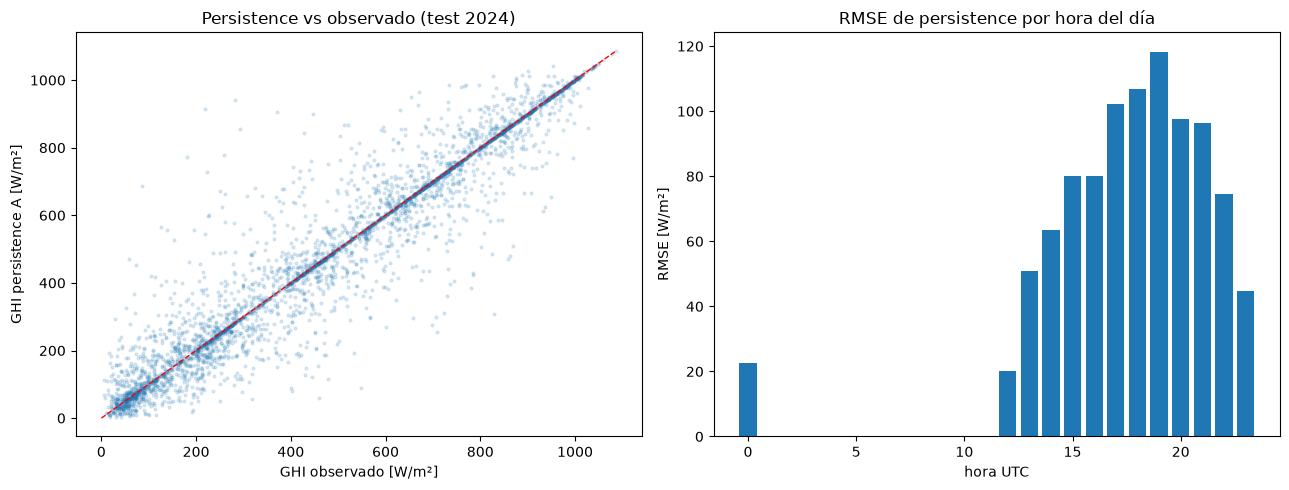

In [4]:
test = per[(per.index.year == 2024) & per['op']].copy()

fig, ax = plt.subplots(1, 2, figsize=(13, 5))

# 1) Dispersión GHI predicho (persistence A) vs observado.
ax[0].scatter(test['ghi_true'], test['ghi_pred_A'], s=4, alpha=0.15)
lim = [0, test['ghi_true'].max()]
ax[0].plot(lim, lim, 'r--', lw=1)
ax[0].set_xlabel('GHI observado [W/m²]')
ax[0].set_ylabel('GHI persistence A [W/m²]')
ax[0].set_title('Persistence vs observado (test 2024)')

# 2) RMSE por hora local del día.
test['err2'] = (test['ghi_pred_A'] - test['ghi_true']) ** 2
rmse_hora = test.groupby(test.index.hour)['err2'].mean() ** 0.5
ax[1].bar(rmse_hora.index, rmse_hora.values)
ax[1].set_xlabel('hora UTC')
ax[1].set_ylabel('RMSE [W/m²]')
ax[1].set_title('RMSE de persistence por hora del día')
plt.tight_layout()
plt.show()

## Conclusión

El baseline queda establecido. `RMSE_ref` (variante A, GHI reconstruido) es la
referencia de la Fase 3: **el primer XGBoost debe lograr skill > 0** sobre estos
valores. Persistence ya reduce ~52–54 % el RMSE frente a suponer cielo despejado
(kt=1). El segmento rellenado (ff>0) tiene menor RMSE (dato interpolado más suave =
más persistente); se seguirá reportando segmentado. Ver `docs/fase2_baseline.md`.